In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import logging 
logging.basicConfig(level=logging.INFO)

In [23]:
from detectors.models.zoo import ModelRegistry, HuggingFaceConfig, HuggingFaceDetector
registry = ModelRegistry()

# Register a model
config = HuggingFaceConfig(
    model_name="bert-base-uncased",
    num_labels=2,
    max_length=512
)
registry.register_model("bert-base", HuggingFaceDetector, config)

# Get a model instance
model = registry.get_model("bert-base")
model.model.config.id2label = {0: "gpt-4o-mini", 1: "human"}

INFO:detectors.models.zoo.implementations:Initializing HuggingFaceDetector with device: cuda
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [24]:
model.get_labels()

['gpt-4o-mini', 'human']

In [3]:
from detectors.data.datasets import load_from_huggingface

In [25]:
dataset = load_from_huggingface(
        "anakib1/mango-truth",
        backend_type="pandas",
        config="xlsum",
        split="train",
        author_column='user_id'
    )

dataset = dataset.shuffle()[:128]

INFO:detectors.data.datasets.loaders.huggingface_loader:Loaded dataset anakib1/mango-truth (config: xlsum)


INFO:detectors.models.zoo.evaluation:Initializing ModelEvaluator for model: HuggingFaceDetector
INFO:detectors.models.zoo.evaluation:Dataset labels: ['gpt-4o-mini', 'human']
INFO:detectors.models.zoo.evaluation:Model labels: ['gpt-4o-mini', 'human']
Evaluating: 100%|██████████| 4/4 [00:00<00:00,  4.26it/s]


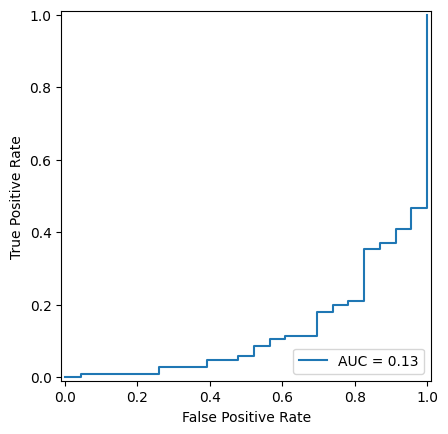

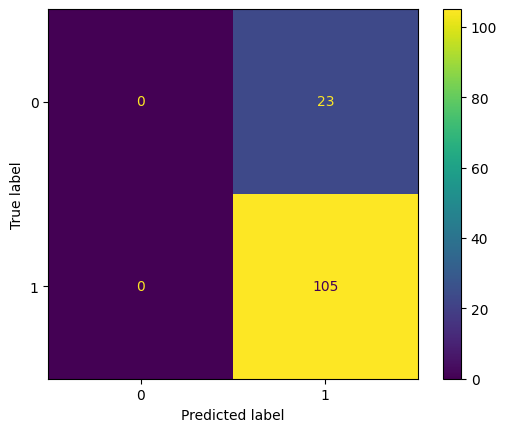

In [26]:
from detectors.models.zoo.evaluation import evaluate

res = evaluate(model, dataset)